# 🌊 FluidWorld — Démonstration des principes fondamentaux

> **Papier :** *FLUIDWORLD: Reaction-Diffusion Dynamics as a Predictive Substrate for World Models*
> **Auteur :** Fabien Polly (2026) — arXiv:2603.21315

Ce notebook implémente et visualise les mécanismes clés du papier :

1. **Le Laplacien discret** — propagation spatiale O(N)
2. **Dynamique réaction-diffusion** — l'EDP comme prédicteur
3. **Diffusion multi-échelle** — dilations {1, 4, 16}
4. **Auto-réparation (autopoïèse)** — le Laplacien comme filtre correcteur
5. **Calcul adaptatif** — convergence et arrêt anticipé
6. **BeliefField** — état persistant avec écriture/évolution/lecture
7. **Mécanismes bio-inspirés** — inhibition latérale, fatigue synaptique
8. **Comparaison de complexité** — O(N) vs O(N²)


## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import convolve, gaussian_filter, zoom
from scipy.signal import convolve2d
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0a0b0f',
    'axes.facecolor': '#12131a',
    'axes.edgecolor': '#2a3050',
    'axes.labelcolor': '#c8cad4',
    'text.color': '#c8cad4',
    'xtick.color': '#6b6f82',
    'ytick.color': '#6b6f82',
    'grid.color': '#1e2030',
    'grid.alpha': 0.5,
    'font.family': 'monospace',
    'font.size': 10,
    'figure.dpi': 130,
})

fluid_colors = LinearSegmentedColormap.from_list(
    'fluid', ['#0a0b0f', '#1a3a6a', '#4a7fff', '#22d3ee', '#34d399', '#f0fdf4'])
diverging = LinearSegmentedColormap.from_list(
    'div', ['#ef4444', '#1e2030', '#22d3ee'])

print("Setup complet")


Setup complet


## 1. Le Laplacien discret — cœur de FluidWorld

Le Laplacien est **l'unique opérateur de propagation spatiale** dans FluidWorld. Il remplace entièrement l'auto-attention des Transformers.

En 1D : `nabla^2 u_i = u_{i-1} + u_{i+1} - 2*u_i`

**Propriété clé :** il mesure la différence entre une position et ses voisins. Si une position est plus élevée que la moyenne de ses voisins, le Laplacien est négatif → la diffusion la réduit. C'est un **filtre passe-bas naturel**.


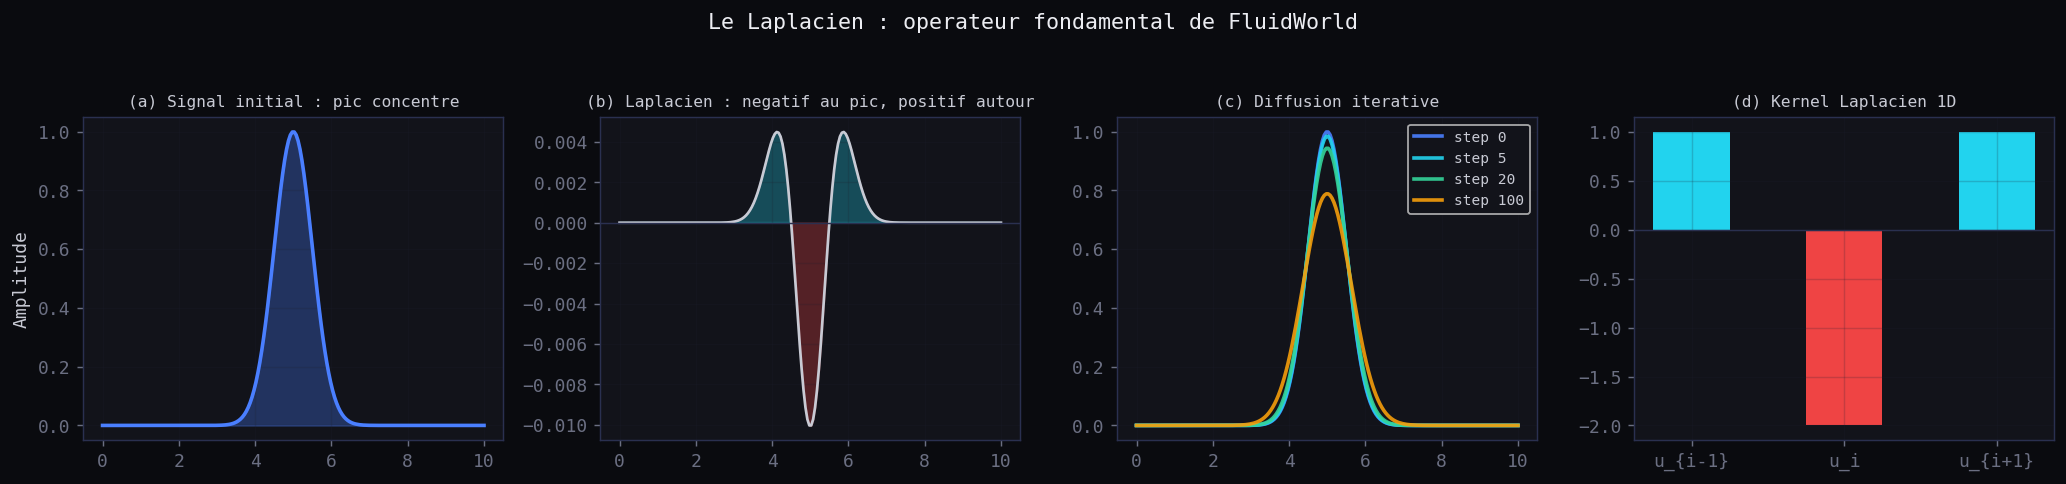

In [2]:
# Le Laplacien 1D : diffusion d'un pic
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

x = np.linspace(0, 10, 200)
u = np.exp(-0.5 * ((x - 5) / 0.5)**2)
kernel_1d = np.array([1, -2, 1])

axes[0].fill_between(x, u, alpha=0.3, color='#4a7fff')
axes[0].plot(x, u, color='#4a7fff', lw=2)
axes[0].set_title('(a) Signal initial : pic concentre', fontsize=9)
axes[0].set_ylabel('Amplitude')

lap_u = np.convolve(u, kernel_1d, mode='same')
axes[1].fill_between(x, lap_u, alpha=0.3, color='#ef4444', where=lap_u < 0)
axes[1].fill_between(x, lap_u, alpha=0.3, color='#22d3ee', where=lap_u > 0)
axes[1].plot(x, lap_u, color='#c8cad4', lw=1.5)
axes[1].axhline(0, color='#2a3050', lw=0.8)
axes[1].set_title('(b) Laplacien : negatif au pic, positif autour', fontsize=9)

dt, D = 0.3, 1.0
u_diffused = u.copy()
steps = [0, 5, 20, 100]
colors_diff = ['#4a7fff', '#22d3ee', '#34d399', '#f59e0b']
for step in range(max(steps) + 1):
    if step in steps:
        idx = steps.index(step)
        axes[2].plot(x, u_diffused, color=colors_diff[idx], lw=2, label=f'step {step}', alpha=0.9)
    lap = np.convolve(u_diffused, kernel_1d, mode='same')
    u_diffused = u_diffused + dt * D * lap
    u_diffused[0] = u_diffused[-1] = 0

axes[2].legend(fontsize=8)
axes[2].set_title('(c) Diffusion iterative', fontsize=9)

bar_x = ['u_{i-1}', 'u_i', 'u_{i+1}']
axes[3].bar(bar_x, kernel_1d, color=['#22d3ee', '#ef4444', '#22d3ee'], width=0.5)
axes[3].axhline(0, color='#2a3050', lw=0.8)
axes[3].set_title('(d) Kernel Laplacien 1D', fontsize=9)

for ax in axes: ax.grid(True, alpha=0.2)
plt.suptitle('Le Laplacien : operateur fondamental de FluidWorld', fontsize=12, color='#ecedf2', y=1.05)
plt.tight_layout()
plt.show()


## 2. Diffusion 2D — l'equation de la chaleur

En 2D, le stencil Laplacien a 5 points : `[[0,1,0],[1,-4,1],[0,1,0]]`. Un point chaud se propage vers ses voisins jusqu'a l'equilibre. C'est ce mecanisme qui remplace l'attention pour la communication entre positions spatiales.


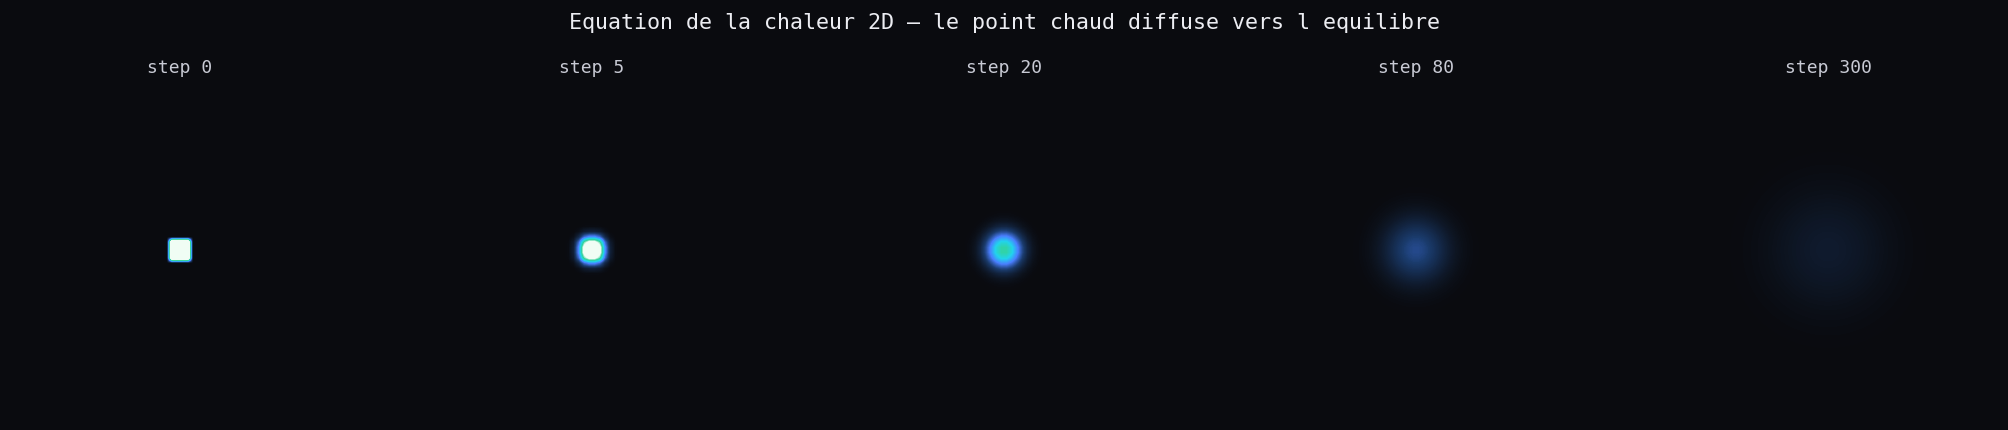

Le Laplacien propage l information spatiale, SANS attention, en O(N).


In [3]:
# Equation de la chaleur 2D
N = 64
K_lap_2d = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

u = np.zeros((N, N))
u[N//2-2:N//2+2, N//2-2:N//2+2] = 1.0

D, dt = 0.2, 0.5
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
snapshots = [0, 5, 20, 80, 300]

u_evolve = u.copy()
for step in range(max(snapshots) + 1):
    if step in snapshots:
        idx = snapshots.index(step)
        axes[idx].imshow(u_evolve, cmap=fluid_colors, vmin=0, vmax=0.6, interpolation='bilinear')
        axes[idx].set_title(f'step {step}', fontsize=10)
        axes[idx].axis('off')
    lap = convolve2d(u_evolve, K_lap_2d, mode='same', boundary='wrap')
    u_evolve = u_evolve + dt * D * lap

plt.suptitle('Equation de la chaleur 2D — le point chaud diffuse vers l equilibre', fontsize=12, color='#ecedf2', y=1.02)
plt.tight_layout()
plt.show()
print("Le Laplacien propage l information spatiale, SANS attention, en O(N).")


## 3. Laplacien multi-echelle — dilations {1, 4, 16}

Innovation cle : utiliser le Laplacien a **trois echelles de dilation** pour propager l'information a differentes portees spatiales. Dilations {1, 4, 16} donnent des champs receptifs de 3, 9 et 33 pixels en feature space.


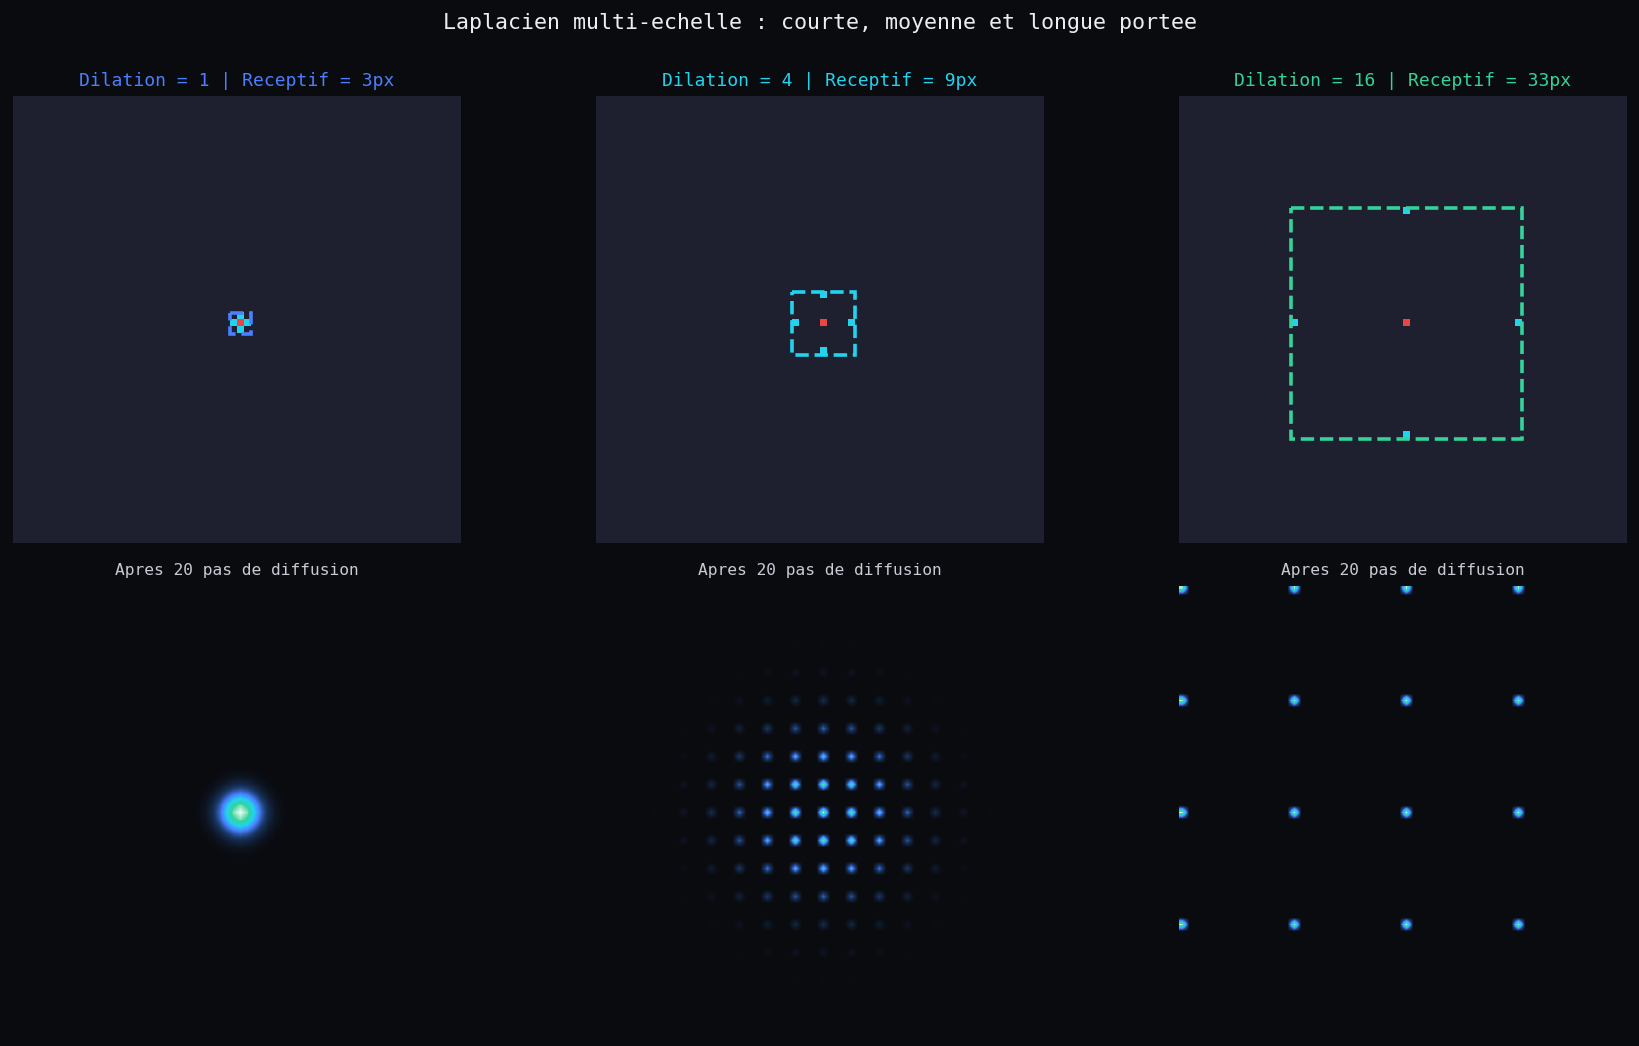

Dilation 1: 3px | Dilation 4: 9px (36px input) | Dilation 16: 33px (132px input)


In [4]:
# Laplacien multi-echelle
def dilated_laplacian_2d(u, dilation):
    N = u.shape[0]
    d = dilation
    lap = np.zeros_like(u)
    for di, dj in [(0, d), (0, -d), (d, 0), (-d, 0)]:
        lap += np.roll(np.roll(u, -di, axis=0), -dj, axis=1)
    lap -= 4 * u
    return lap

N = 64
u = np.zeros((N, N))
u[N//2, N//2] = 1.0

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
dilations = [1, 4, 16]
colors_d = ['#4a7fff', '#22d3ee', '#34d399']

for i, dil in enumerate(dilations):
    lap = dilated_laplacian_2d(u, dil)
    axes[0, i].imshow(lap, cmap=diverging, interpolation='nearest', vmin=-0.5, vmax=0.5)
    axes[0, i].set_title(f'Dilation = {dil} | Receptif = {2*dil+1}px', fontsize=10, color=colors_d[i])
    axes[0, i].axis('off')
    center = N // 2
    rect = plt.Rectangle((center - dil - 0.5, center - dil - 0.5), 2*dil + 1, 2*dil + 1,
                          fill=False, edgecolor=colors_d[i], lw=2, ls='--')
    axes[0, i].add_patch(rect)

for i, dil in enumerate(dilations):
    u_d = u.copy()
    for _ in range(20):
        lap = dilated_laplacian_2d(u_d, dil)
        u_d = u_d + 0.1 * lap
    axes[1, i].imshow(u_d, cmap=fluid_colors, interpolation='bilinear', vmin=0)
    axes[1, i].set_title('Apres 20 pas de diffusion', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('1 pas', fontsize=10, color='#ecedf2')
axes[1, 0].set_ylabel('20 pas', fontsize=10, color='#ecedf2')
plt.suptitle('Laplacien multi-echelle : courte, moyenne et longue portee', fontsize=12, color='#ecedf2', y=1.0)
plt.tight_layout()
plt.show()
print("Dilation 1: 3px | Dilation 4: 9px (36px input) | Dilation 16: 33px (132px input)")


## 4. Dynamique reaction-diffusion complete

L'equation fondamentale combine **diffusion** (propagation spatiale) et **reaction** (transformation non-lineaire locale) :

`u^(t+1) = u^(t) + dt * [ D * Lap(u) + R(u) ]`

- **Diffusion** : propage l'information entre voisins (comme la communication inter-tokens)
- **Reaction** : transformation non-lineaire par position (comme le FFN d'un Transformer)


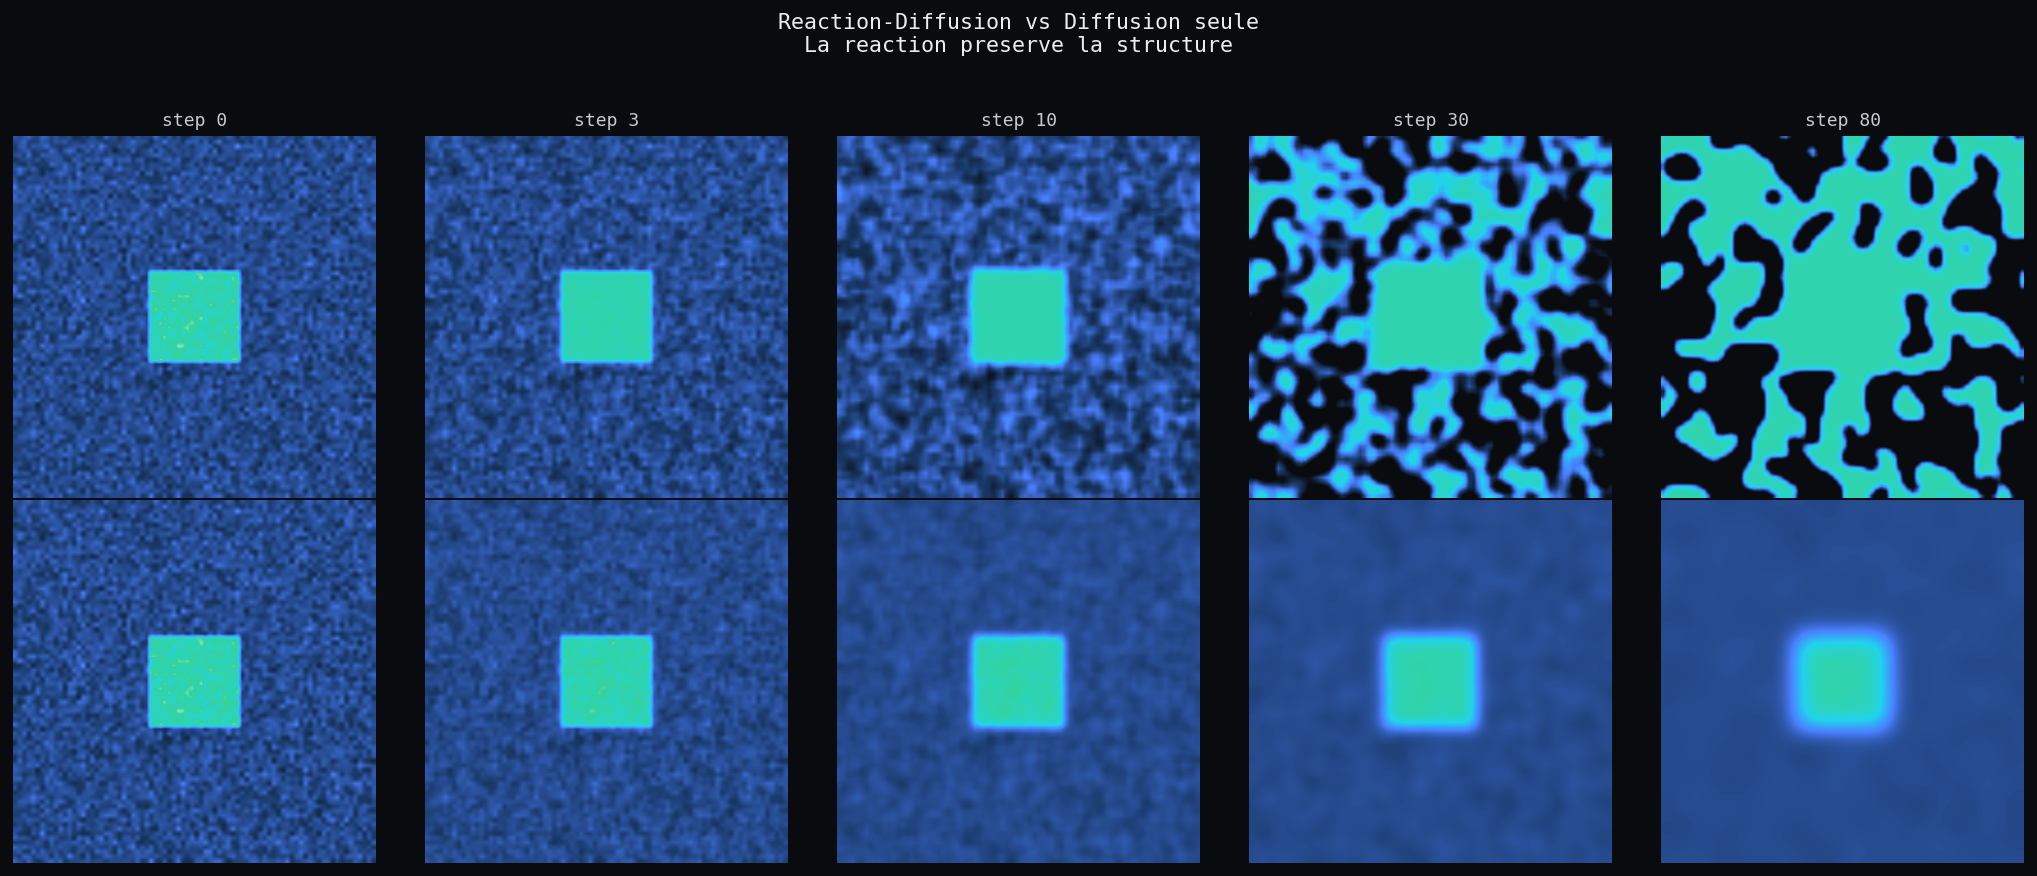

Diffusion seule: tout converge vers la moyenne.
Reaction + Diffusion: formation de PATTERNS stables.


In [5]:
# Reaction-Diffusion 2D : formation de patterns
N = 80
np.random.seed(42)
u = np.random.randn(N, N) * 0.1
u[30:50, 30:50] += 1.0

D_coeff, dt = 0.15, 0.3
K_lap_2d = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

def reaction(u):
    return u * (1.0 - u**2) * 0.5

fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
u_rd = u.copy()
u_diff_only = u.copy()
snapshots = [0, 3, 10, 30, 80]

for step in range(max(snapshots) + 1):
    if step in snapshots:
        idx = snapshots.index(step)
        axes[0, idx].imshow(u_rd, cmap=fluid_colors, vmin=-0.5, vmax=1.5, interpolation='bilinear')
        axes[0, idx].set_title(f'step {step}', fontsize=10)
        axes[0, idx].axis('off')
        axes[1, idx].imshow(u_diff_only, cmap=fluid_colors, vmin=-0.5, vmax=1.5, interpolation='bilinear')
        axes[1, idx].axis('off')

    lap = convolve2d(u_rd, K_lap_2d, mode='same', boundary='wrap')
    u_rd = np.clip(u_rd + dt * (D_coeff * lap + reaction(u_rd)), -3, 3)
    lap_d = convolve2d(u_diff_only, K_lap_2d, mode='same', boundary='wrap')
    u_diff_only = u_diff_only + dt * D_coeff * lap_d

axes[0, 0].set_ylabel('Reaction +\nDiffusion', fontsize=10, color='#ecedf2')
axes[1, 0].set_ylabel('Diffusion\nseule', fontsize=10, color='#ecedf2')
plt.suptitle('Reaction-Diffusion vs Diffusion seule\nLa reaction preserve la structure', fontsize=12, color='#ecedf2', y=1.03)
plt.tight_layout()
plt.show()
print("Diffusion seule: tout converge vers la moyenne.")
print("Reaction + Diffusion: formation de PATTERNS stables.")


## 5. Auto-reparation — le resultat central du papier

**Contribution la plus importante.** Le Laplacien agit comme un filtre passe-bas qui lisse les erreurs haute frequence. En rollout autoregressif :

1. Le modele accumule des erreurs (bruit HF)
2. Le Laplacien dissipe ce bruit a chaque pas
3. Resultat : cycle accumulation -> dissipation

Les Transformers et ConvLSTMs n'ont **aucun mecanisme equivalent**.


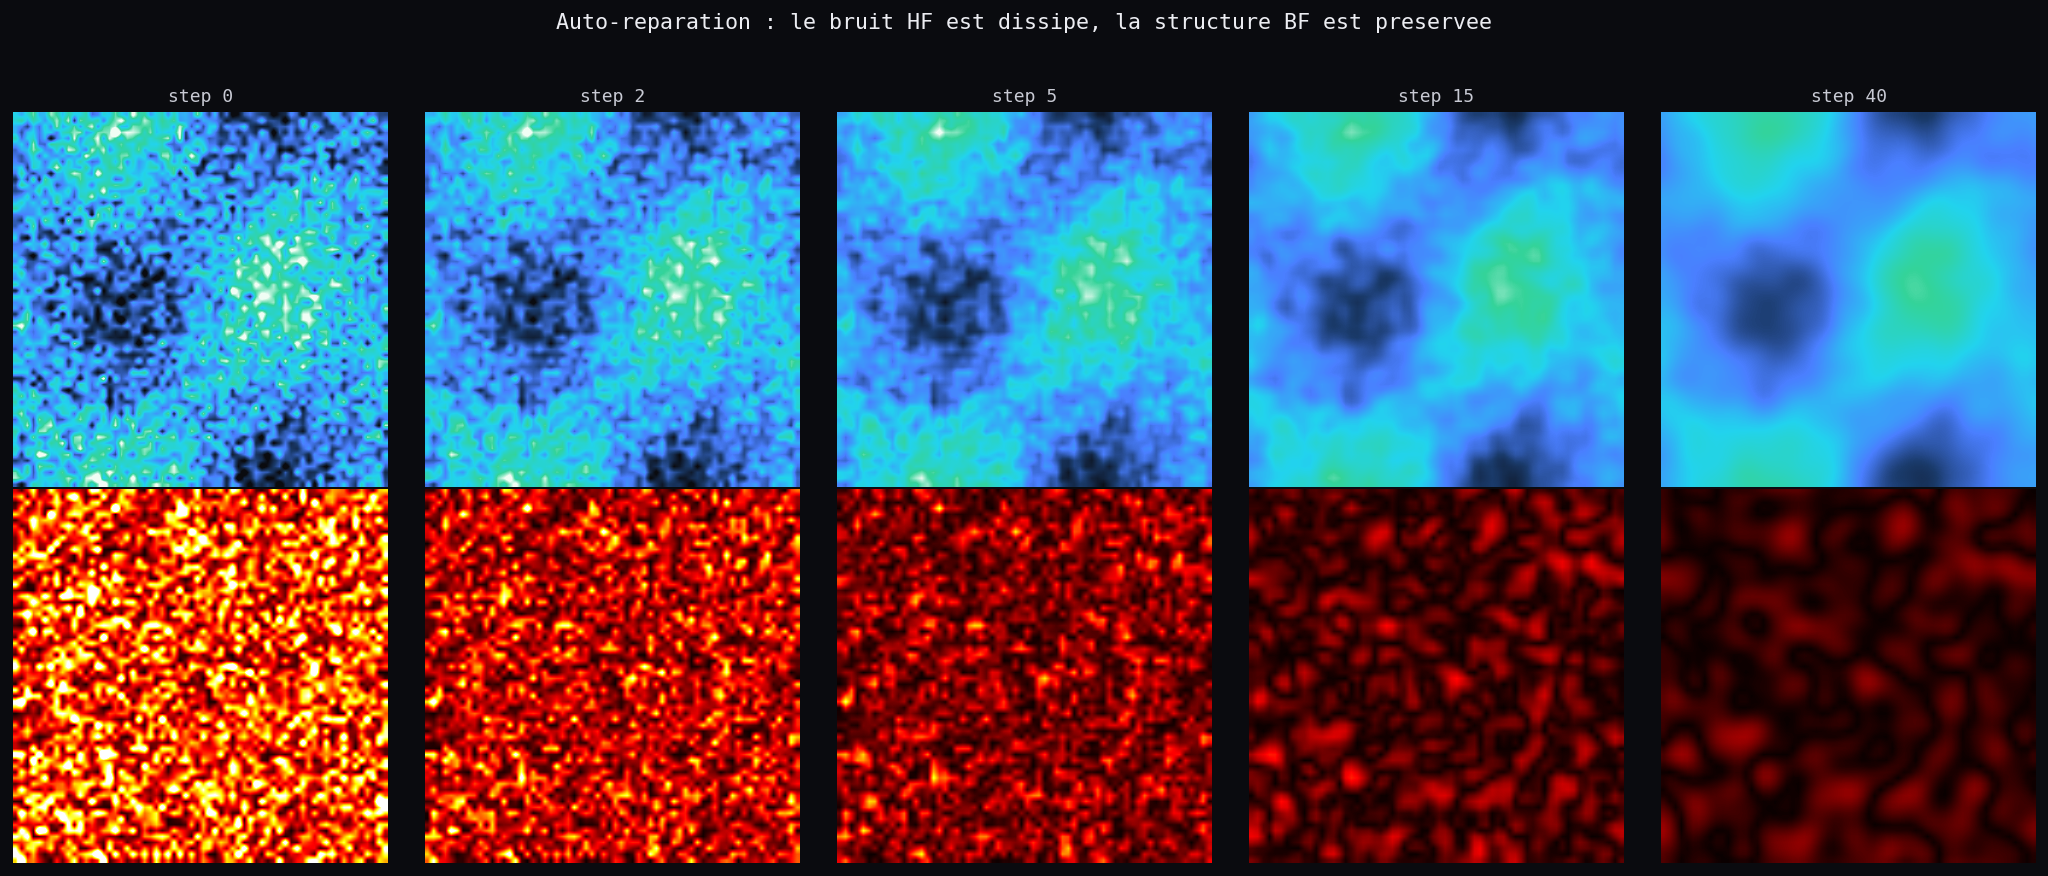

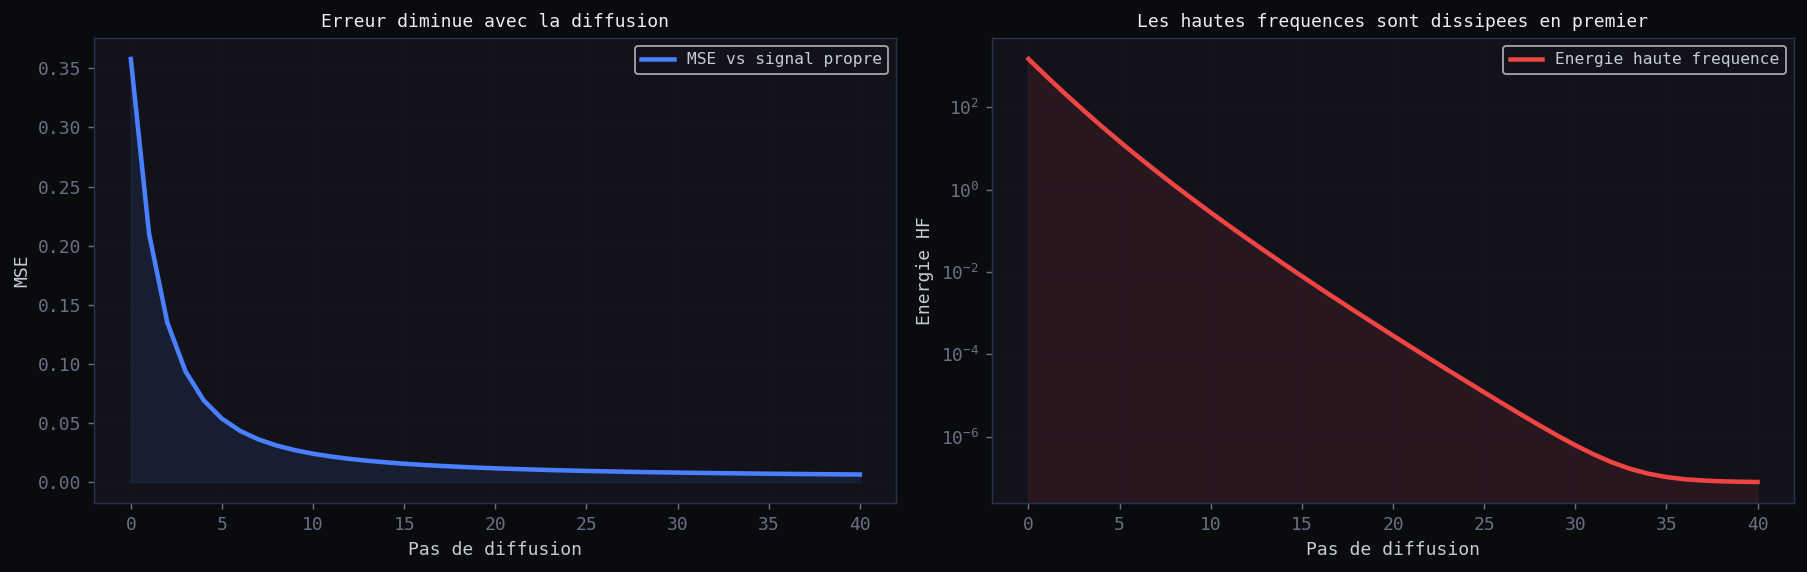

MSE initiale : 0.3579
MSE finale   : 0.0063
Reduction    : 56.4x


In [6]:
# Auto-reparation par diffusion Laplacienne
N = 64
K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

x = np.linspace(-3, 3, N)
xx, yy = np.meshgrid(x, x)
clean_signal = np.sin(xx) * np.cos(yy) * 0.8 + 0.2 * np.sin(2*xx + yy)

np.random.seed(42)
noise = np.random.randn(N, N) * 0.6
corrupted = clean_signal + noise

D_repair, dt_repair = 0.2, 0.3
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
repair_steps = [0, 2, 5, 15, 40]

mse_history = []
hf_history = []
u_repair = corrupted.copy()

for step in range(max(repair_steps) + 1):
    mse = np.mean((u_repair - clean_signal)**2)
    fft = np.fft.fft2(u_repair - clean_signal)
    hf = np.mean(np.abs(fft[N//4:3*N//4, N//4:3*N//4])**2)
    mse_history.append(mse)
    hf_history.append(hf)

    if step in repair_steps:
        idx = repair_steps.index(step)
        axes[0, idx].imshow(u_repair, cmap=fluid_colors, vmin=-1.5, vmax=1.5, interpolation='bilinear')
        axes[0, idx].set_title(f'step {step}', fontsize=10)
        axes[0, idx].axis('off')
        error_map = np.abs(u_repair - clean_signal)
        axes[1, idx].imshow(error_map, cmap='hot', vmin=0, vmax=1.0, interpolation='bilinear')
        axes[1, idx].axis('off')

    lap = convolve2d(u_repair, K_lap, mode='same', boundary='wrap')
    u_repair = u_repair + dt_repair * D_repair * lap

axes[0, 0].set_ylabel('Signal\nrepare', fontsize=10, color='#ecedf2')
axes[1, 0].set_ylabel('Carte\nd erreur', fontsize=10, color='#ecedf2')
plt.suptitle('Auto-reparation : le bruit HF est dissipe, la structure BF est preservee', fontsize=12, color='#ecedf2', y=1.03)
plt.tight_layout()
plt.show()

# Quantification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(mse_history, color='#4a7fff', lw=2.5, label='MSE vs signal propre')
ax1.fill_between(range(len(mse_history)), mse_history, alpha=0.1, color='#4a7fff')
ax1.set_xlabel('Pas de diffusion')
ax1.set_ylabel('MSE')
ax1.set_title('Erreur diminue avec la diffusion', fontsize=10, color='#ecedf2')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

ax2.plot(hf_history, color='#ef4444', lw=2.5, label='Energie haute frequence')
ax2.fill_between(range(len(hf_history)), hf_history, alpha=0.1, color='#ef4444')
ax2.set_xlabel('Pas de diffusion')
ax2.set_ylabel('Energie HF')
ax2.set_yscale('log')
ax2.set_title('Les hautes frequences sont dissipees en premier', fontsize=10, color='#ecedf2')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"MSE initiale : {mse_history[0]:.4f}")
print(f"MSE finale   : {mse_history[-1]:.4f}")
print(f"Reduction    : {mse_history[0]/mse_history[-1]:.1f}x")


## 6. Simulation de rollout autoregressif : PDE vs sans diffusion

A chaque pas de rollout :
- Une erreur de prediction est ajoutee (bruit)
- Le modele PDE applique un pas de diffusion Laplacienne (lisse l'erreur)
- Le modele sans diffusion accumule l'erreur sans correction

C'est la **Figure 7 du papier** : le PDE montre une recuperation oscillatoire.


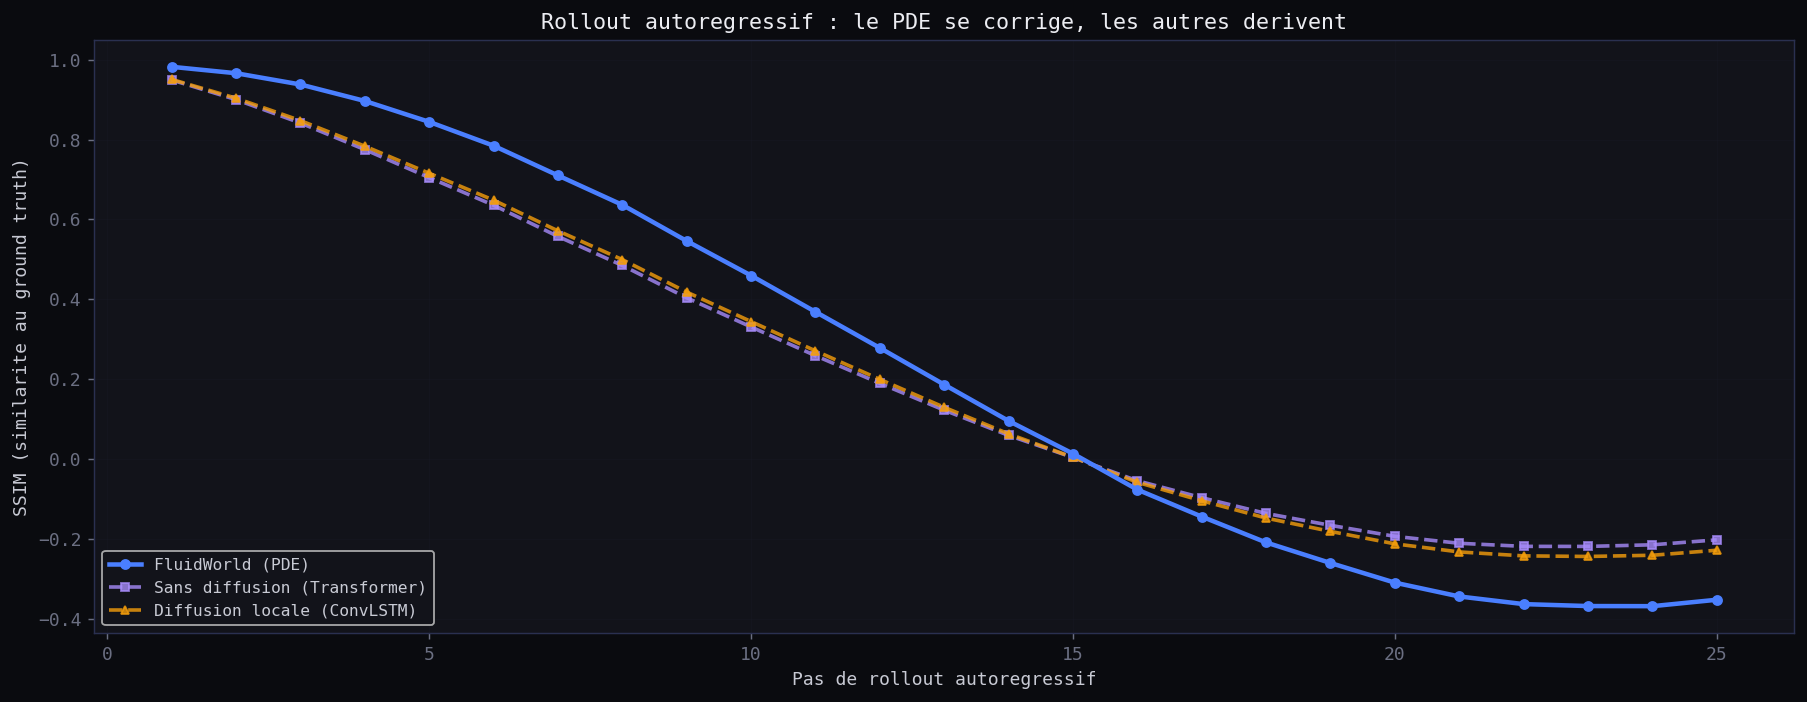

Le Laplacien agit comme un systeme immunitaire :
  Erreurs = bruit haute frequence
  Laplacien = filtre passe-bas
  -> Les erreurs sont dissipees a chaque pas d integration


In [7]:
# Simulation de rollout autoregressif
np.random.seed(42)
N = 64
K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

x = np.linspace(-3, 3, N)
xx, yy = np.meshgrid(x, x)

def ground_truth(t):
    return np.sin(xx + 0.1*t) * np.cos(yy - 0.05*t) * 0.8 + 0.3 * np.sin(2*xx + 0.15*t + yy)

def ssim_simple(a, b):
    a_n = (a - a.mean()) / (a.std() + 1e-8)
    b_n = (b - b.mean()) / (b.std() + 1e-8)
    return np.mean(a_n * b_n)

n_steps = 25
noise_level = 0.15

pred_pde = ground_truth(0).copy()
pred_nodiff = ground_truth(0).copy()
pred_local = ground_truth(0).copy()
ssim_pde, ssim_nodiff, ssim_local = [], [], []

for t in range(n_steps):
    gt = ground_truth(t)
    noise = np.random.randn(N, N) * noise_level

    # PDE: erreur + diffusion Laplacienne (3 pas)
    pred_pde = pred_pde + noise
    for _ in range(3):
        lap = convolve2d(pred_pde, K_lap, mode='same', boundary='wrap')
        pred_pde = pred_pde + 0.4 * 0.12 * lap

    # Sans diffusion : erreur s'accumule
    pred_nodiff = pred_nodiff + noise

    # Local (ConvLSTM-like) : petit lissage gaussien
    pred_local = pred_local + noise
    pred_local = gaussian_filter(pred_local, sigma=0.3)

    ssim_pde.append(ssim_simple(pred_pde, gt))
    ssim_nodiff.append(ssim_simple(pred_nodiff, gt))
    ssim_local.append(ssim_simple(pred_local, gt))

fig, ax = plt.subplots(figsize=(14, 5.5))
steps_x = range(1, n_steps + 1)

ax.plot(steps_x, ssim_pde, 'o-', color='#4a7fff', lw=2.5, markersize=5, label='FluidWorld (PDE)', zorder=3)
ax.plot(steps_x, ssim_nodiff, 's--', color='#a78bfa', lw=2, markersize=4, label='Sans diffusion (Transformer)', alpha=0.8)
ax.plot(steps_x, ssim_local, '^--', color='#f59e0b', lw=2, markersize=4, label='Diffusion locale (ConvLSTM)', alpha=0.8)

# Zone de recuperation
min_idx = np.argmin(ssim_pde[:15])
max_after = min_idx + np.argmax(ssim_pde[min_idx:min_idx+8])
if max_after > min_idx:
    ax.axvspan(min_idx + 1, max_after + 1, alpha=0.08, color='#34d399', label='Zone de recuperation PDE')

ax.set_xlabel('Pas de rollout autoregressif', fontsize=10)
ax.set_ylabel('SSIM (similarite au ground truth)', fontsize=10)
ax.set_title('Rollout autoregressif : le PDE se corrige, les autres derivent', fontsize=12, color='#ecedf2')
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Le Laplacien agit comme un systeme immunitaire :")
print("  Erreurs = bruit haute frequence")
print("  Laplacien = filtre passe-bas")
print("  -> Les erreurs sont dissipees a chaque pas d integration")


## 7. Calcul adaptatif — arret anticipe

L'integration PDE s'arrete quand le changement relatif tombe sous un seuil epsilon = 0.08 pendant 2 pas consecutifs. Les scenes statiques convergent en ~3 pas, les scenes dynamiques en ~12.


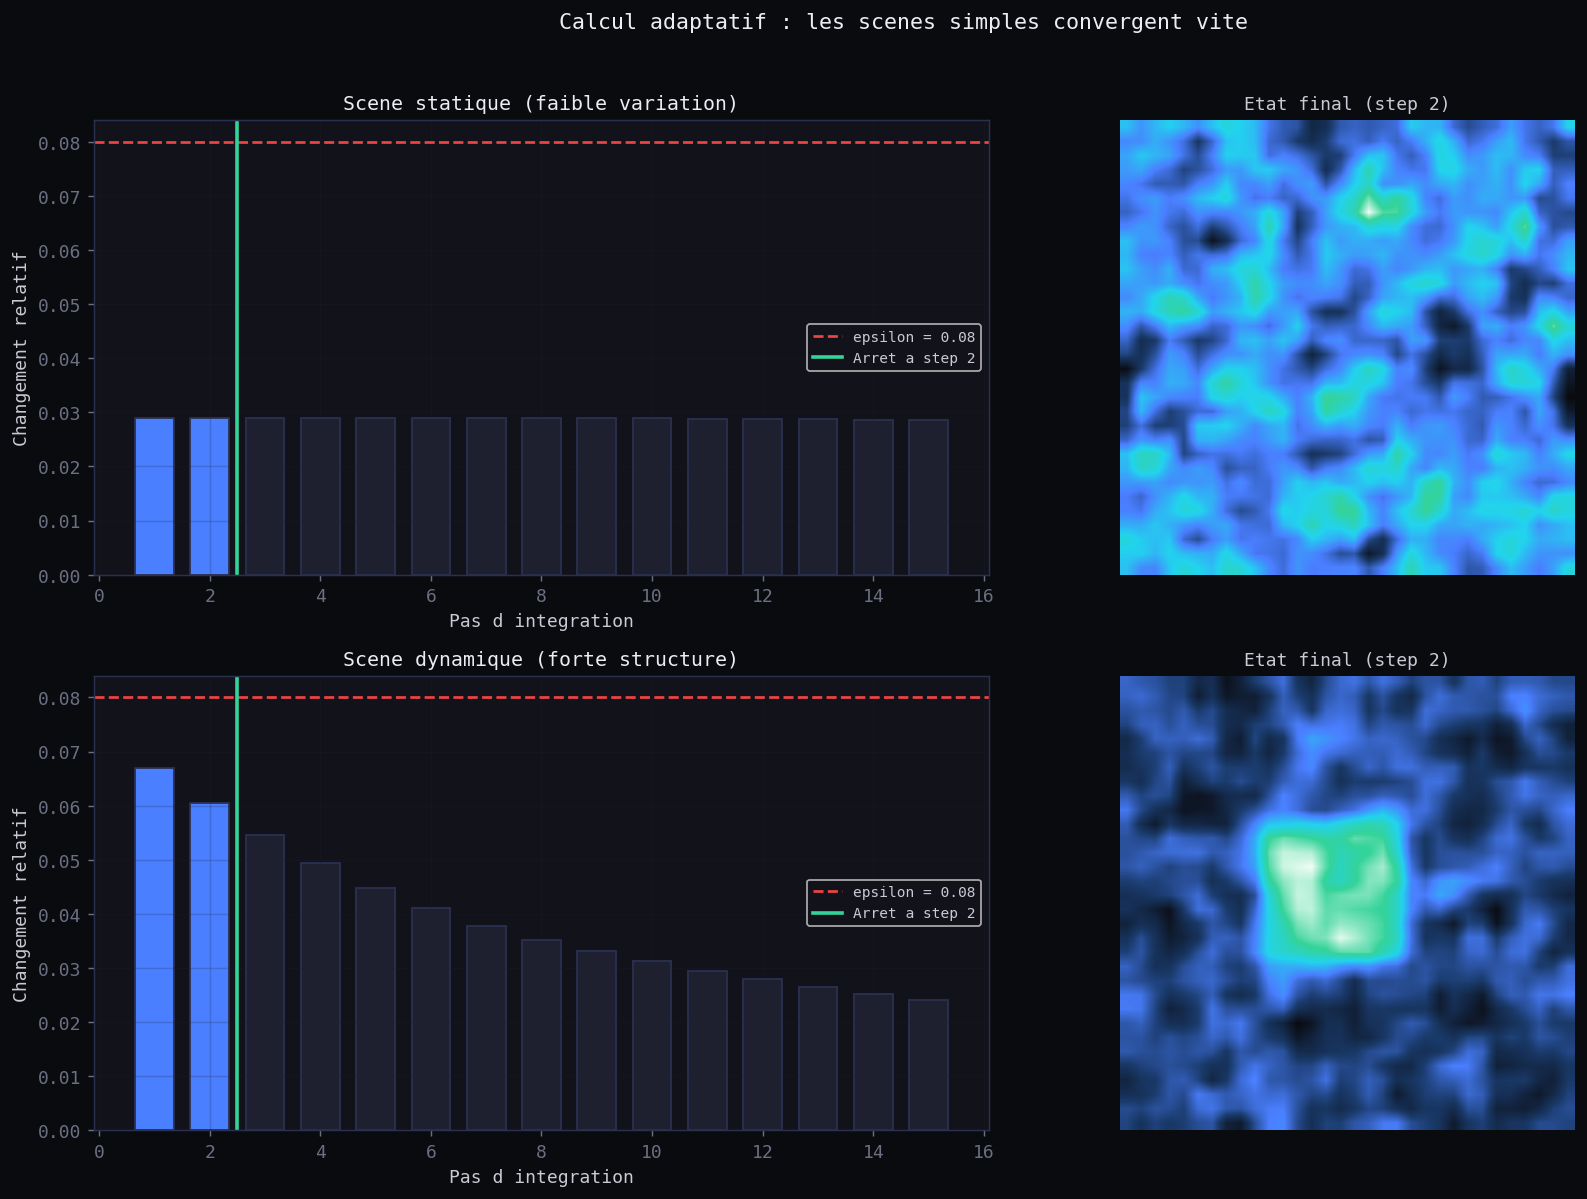

In [8]:
# Calcul adaptatif : convergence de l integration PDE
N = 32
K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

def reaction_mlp(u):
    return np.tanh(u * 0.5) * 0.3

epsilon = 0.08
patience = 2
max_steps = 15
dt, D = 0.2, 0.15

np.random.seed(42)
scenarios = [
    ("Scene statique (faible variation)", np.ones((N, N)) * 0.5 + np.random.randn(N, N) * 0.02),
    ("Scene dynamique (forte structure)", np.random.randn(N, N) * 0.8 + np.pad(np.ones((10,10))*2, ((10,12),(10,12)))),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (name, u_init) in enumerate(scenarios):
    u = u_init.copy()
    changes = []
    stopped_at = max_steps
    patience_counter = 0

    for step in range(max_steps):
        u_prev = u.copy()
        lap = convolve2d(u, K_lap, mode='same', boundary='wrap')
        u = u + dt * (D * lap + reaction_mlp(u))

        probe_prev = zoom(u_prev, 0.25, order=1)
        probe_curr = zoom(u, 0.25, order=1)
        rel_change = np.sum(np.abs(probe_curr - probe_prev)) / (np.sum(np.abs(probe_prev)) + 1e-8)
        changes.append(rel_change)

        if rel_change < epsilon:
            patience_counter += 1
            if patience_counter >= patience and stopped_at == max_steps:
                stopped_at = step + 1
        else:
            patience_counter = 0

    colors_bar = ['#4a7fff' if i < stopped_at else '#1e2030' for i in range(len(changes))]
    axes[row, 0].bar(range(1, len(changes)+1), changes, color=colors_bar, edgecolor='#2a3050', width=0.7)
    axes[row, 0].axhline(epsilon, color='#ef4444', ls='--', lw=1.5, label=f'epsilon = {epsilon}')
    if stopped_at < max_steps:
        axes[row, 0].axvline(stopped_at + 0.5, color='#34d399', ls='-', lw=2, label=f'Arret a step {stopped_at}')
    axes[row, 0].set_xlabel('Pas d integration')
    axes[row, 0].set_ylabel('Changement relatif')
    axes[row, 0].set_title(name, fontsize=11, color='#ecedf2')
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].grid(True, alpha=0.2)

    axes[row, 1].imshow(u, cmap=fluid_colors, interpolation='bilinear')
    axes[row, 1].set_title(f'Etat final (step {stopped_at})', fontsize=10)
    axes[row, 1].axis('off')

plt.suptitle('Calcul adaptatif : les scenes simples convergent vite', fontsize=12, color='#ecedf2', y=1.02)
plt.tight_layout()
plt.show()


## 8. BeliefField — etat temporel persistant

Le BeliefField est un **etat spatial persistant** qui accumule le contexte a travers les frames :

1. **Write** (GRU-gated) : injection de nouvelles observations avec porte apprise
2. **Evolve** : integration PDE interne — le mecanisme de prediction
3. **Read** : extraction des features predites


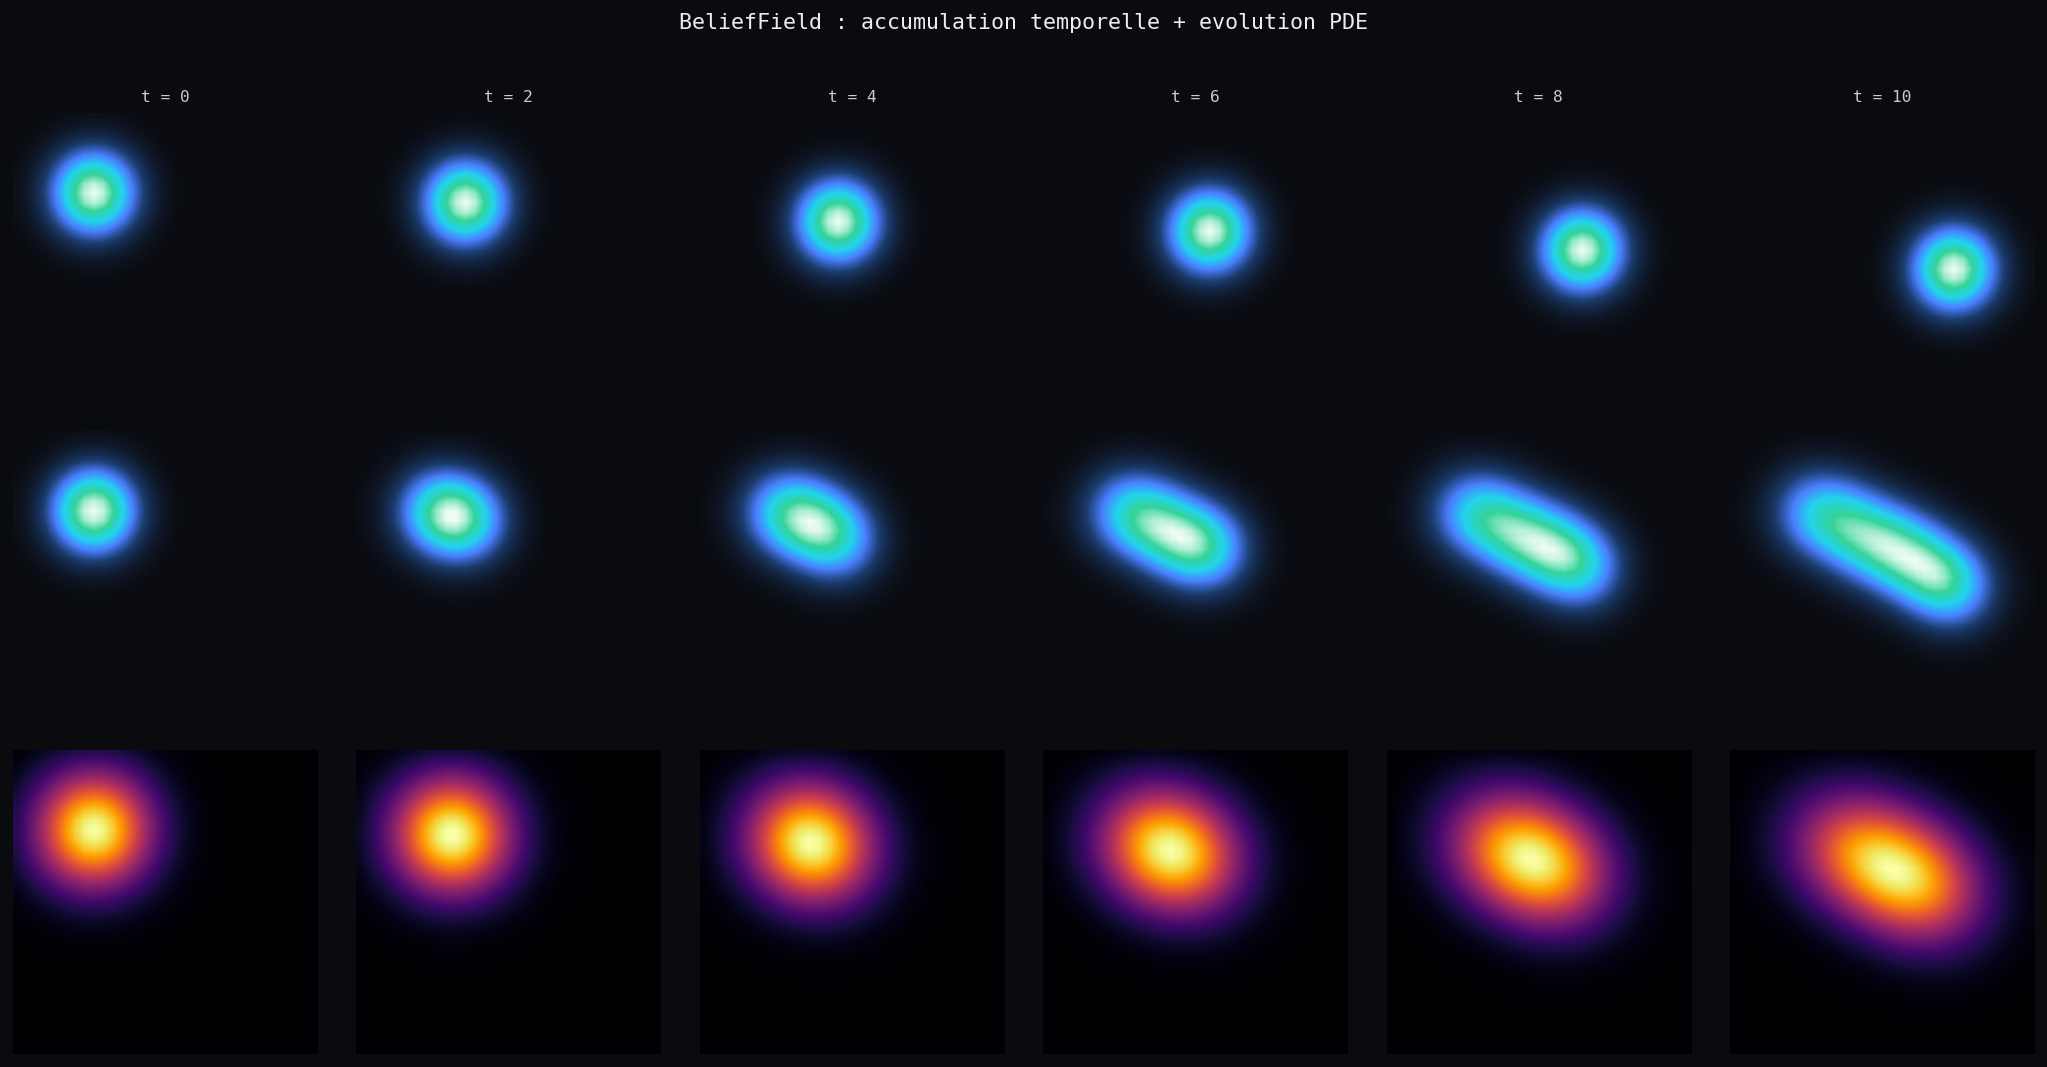

Le BeliefField accumule une trace de l objet en mouvement.
L evolution PDE propage cette information pour predire la position future.


In [9]:
# Simulation du BeliefField
N = 32
n_channels = 4
n_frames = 12
K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)
np.random.seed(42)

def make_frame(t, nc=4, N=32):
    z = np.zeros((nc, N, N))
    cx = int(8 + t * 1.5) % N
    cy = int(8 + t * 0.8) % N
    for c in range(nc):
        y, x = np.mgrid[:N, :N]
        z[c] = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * (3 + c)**2)) * (1 + 0.5*c)
    return z

gamma = 0.92
D_bf, dt_bf = 0.1, 0.2
state = np.zeros((n_channels, N, N))

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
frame_indices = [0, 2, 4, 6, 8, 10]

for fi, t in enumerate(frame_indices):
    z_t = make_frame(t, n_channels, N)

    # WRITE
    gate = 1.0 / (1.0 + np.exp(-z_t * 0.5))
    val = np.tanh(z_t * 0.8)
    state = gamma * state + gate * val

    # EVOLVE (3 PDE steps)
    for _ in range(3):
        for c in range(n_channels):
            lap = convolve2d(state[c], K_lap, mode='same', boundary='wrap')
            state[c] = state[c] + dt_bf * (D_bf * lap + np.tanh(state[c] * 0.3) * 0.1)

    axes[0, fi].imshow(z_t[0], cmap=fluid_colors, interpolation='bilinear')
    axes[0, fi].set_title(f't = {t}', fontsize=9)
    axes[0, fi].axis('off')

    axes[1, fi].imshow(state[0], cmap=fluid_colors, interpolation='bilinear')
    axes[1, fi].axis('off')

    energy = np.sum(state**2, axis=0)
    axes[2, fi].imshow(energy, cmap='inferno', interpolation='bilinear')
    axes[2, fi].axis('off')

axes[0, 0].set_ylabel('Observation', fontsize=10, color='#ecedf2')
axes[1, 0].set_ylabel('BeliefField', fontsize=10, color='#ecedf2')
axes[2, 0].set_ylabel('Energie', fontsize=10, color='#ecedf2')
plt.suptitle('BeliefField : accumulation temporelle + evolution PDE', fontsize=12, color='#ecedf2', y=1.02)
plt.tight_layout()
plt.show()
print("Le BeliefField accumule une trace de l objet en mouvement.")
print("L evolution PDE propage cette information pour predire la position future.")


## 9. Mecanismes bio-inspires

Trois mecanismes pour combattre le **channel collapse** :
- **Inhibition laterale** : les fortes activations suppriment les faibles
- **Fatigue synaptique** : les canaux trop actifs sont attenues
- **Diffusion Hebbienne** : les co-activations renforcent les voies de diffusion


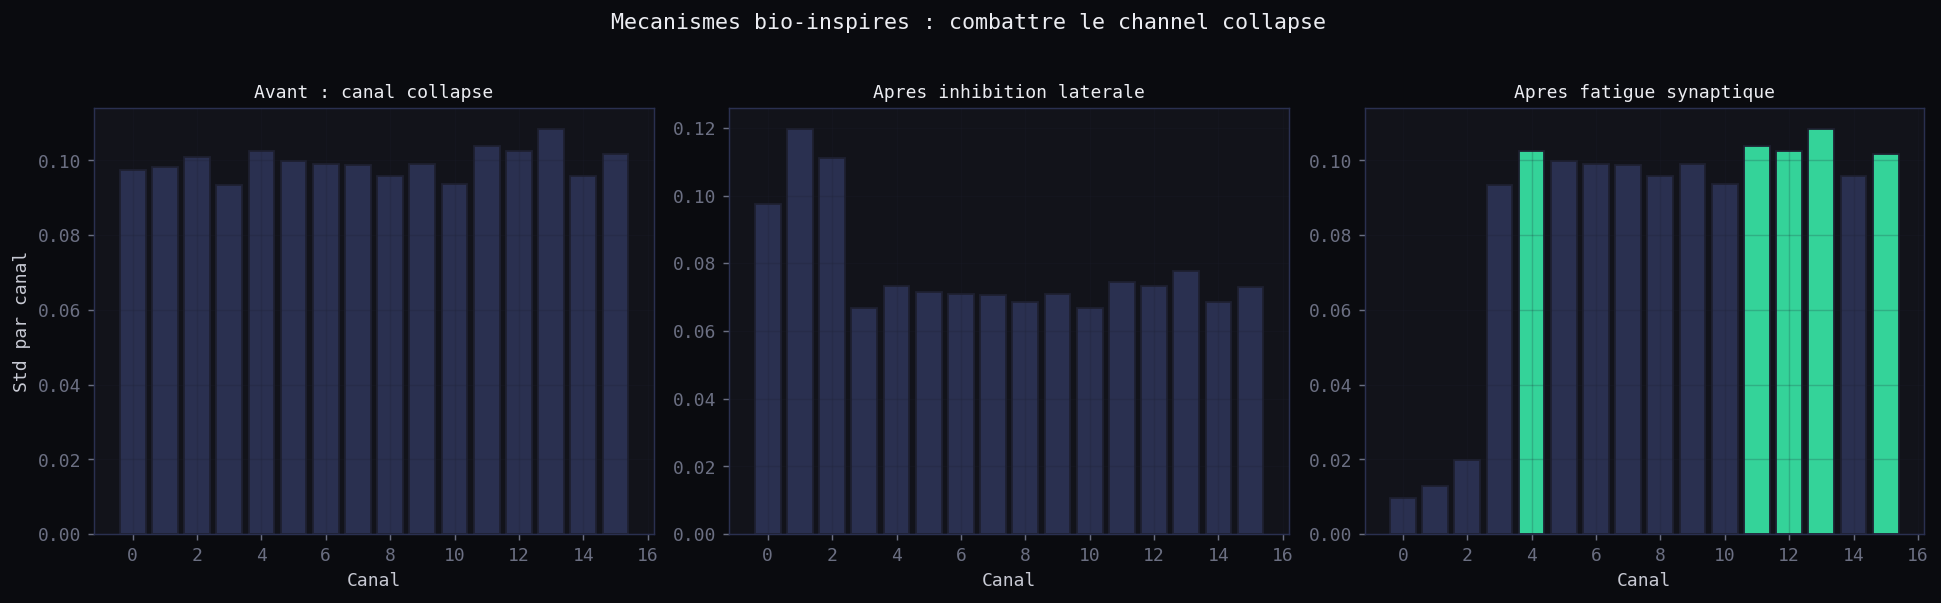

Coefficient de variation (inegalite entre canaux) :
  Avant          : 0.038
  + Inhibition   : 0.200  (reduction -421%)
  + Fatigue      : 0.402  (reduction -949%)


In [10]:
# Mecanismes bio-inspires
np.random.seed(42)
n_channels, N = 16, 16

z = np.random.randn(n_channels, N, N) * 0.1
z[0] += 3.0; z[1] += 2.5; z[2] += 2.0  # Canaux dominants

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# AVANT
energy_before = [np.std(z[c]) for c in range(n_channels)]
axes[0].bar(range(n_channels), energy_before,
            color=['#ef4444' if e > 1.0 else '#2a3050' for e in energy_before], edgecolor='#1e2030')
axes[0].set_title('Avant : canal collapse', fontsize=10, color='#ecedf2')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Std par canal')
axes[0].grid(True, alpha=0.2)

# INHIBITION LATERALE
beta = 0.3
z_inhib = z.copy()
for i in range(N):
    for j in range(N):
        col = z_inhib[:, i, j]
        max_val = np.max(np.abs(col)) + 1e-8
        suppression = 1.0 - beta * (1.0 - np.abs(col) / max_val)
        z_inhib[:, i, j] = col * np.maximum(suppression, 0.2)

energy_inhib = [np.std(z_inhib[c]) for c in range(n_channels)]
axes[1].bar(range(n_channels), energy_inhib,
            color=['#22d3ee' if e > 0.3 else '#2a3050' for e in energy_inhib], edgecolor='#1e2030')
axes[1].set_title('Apres inhibition laterale', fontsize=10, color='#ecedf2')
axes[1].set_xlabel('Canal')
axes[1].grid(True, alpha=0.2)

# FATIGUE SYNAPTIQUE
kappa, rho, h_min = 0.1, 0.02, 0.1
health = np.ones(n_channels)
z_fatigue = z.copy()
for _ in range(10):
    mean_act = np.mean(np.abs(z_fatigue), axis=(1, 2))
    health = np.clip(health - kappa * mean_act + rho, h_min, 1.0)
    z_fatigue = z * health[:, None, None]

energy_fatigue = [np.std(z_fatigue[c]) for c in range(n_channels)]
axes[2].bar(range(n_channels), energy_fatigue,
            color=['#34d399' if e > 0.1 else '#2a3050' for e in energy_fatigue], edgecolor='#1e2030')
axes[2].set_title('Apres fatigue synaptique', fontsize=10, color='#ecedf2')
axes[2].set_xlabel('Canal')
axes[2].grid(True, alpha=0.2)

plt.suptitle('Mecanismes bio-inspires : combattre le channel collapse', fontsize=12, color='#ecedf2', y=1.02)
plt.tight_layout()
plt.show()

gini_before = np.std(energy_before) / np.mean(energy_before)
gini_inhib = np.std(energy_inhib) / np.mean(energy_inhib)
gini_fatigue = np.std(energy_fatigue) / np.mean(energy_fatigue)
print(f"Coefficient de variation (inegalite entre canaux) :")
print(f"  Avant          : {gini_before:.3f}")
print(f"  + Inhibition   : {gini_inhib:.3f}  (reduction {(1 - gini_inhib/gini_before)*100:.0f}%)")
print(f"  + Fatigue      : {gini_fatigue:.3f}  (reduction {(1 - gini_fatigue/gini_before)*100:.0f}%)")


## 10. Complexite computationnelle : O(N) vs O(N^2)

| Operation | Attention | PDE Diffusion | ConvLSTM |
|-----------|-----------|---------------|----------|
| Par couche | O(N^2 * d) | O(N) | O(N * k^2) |


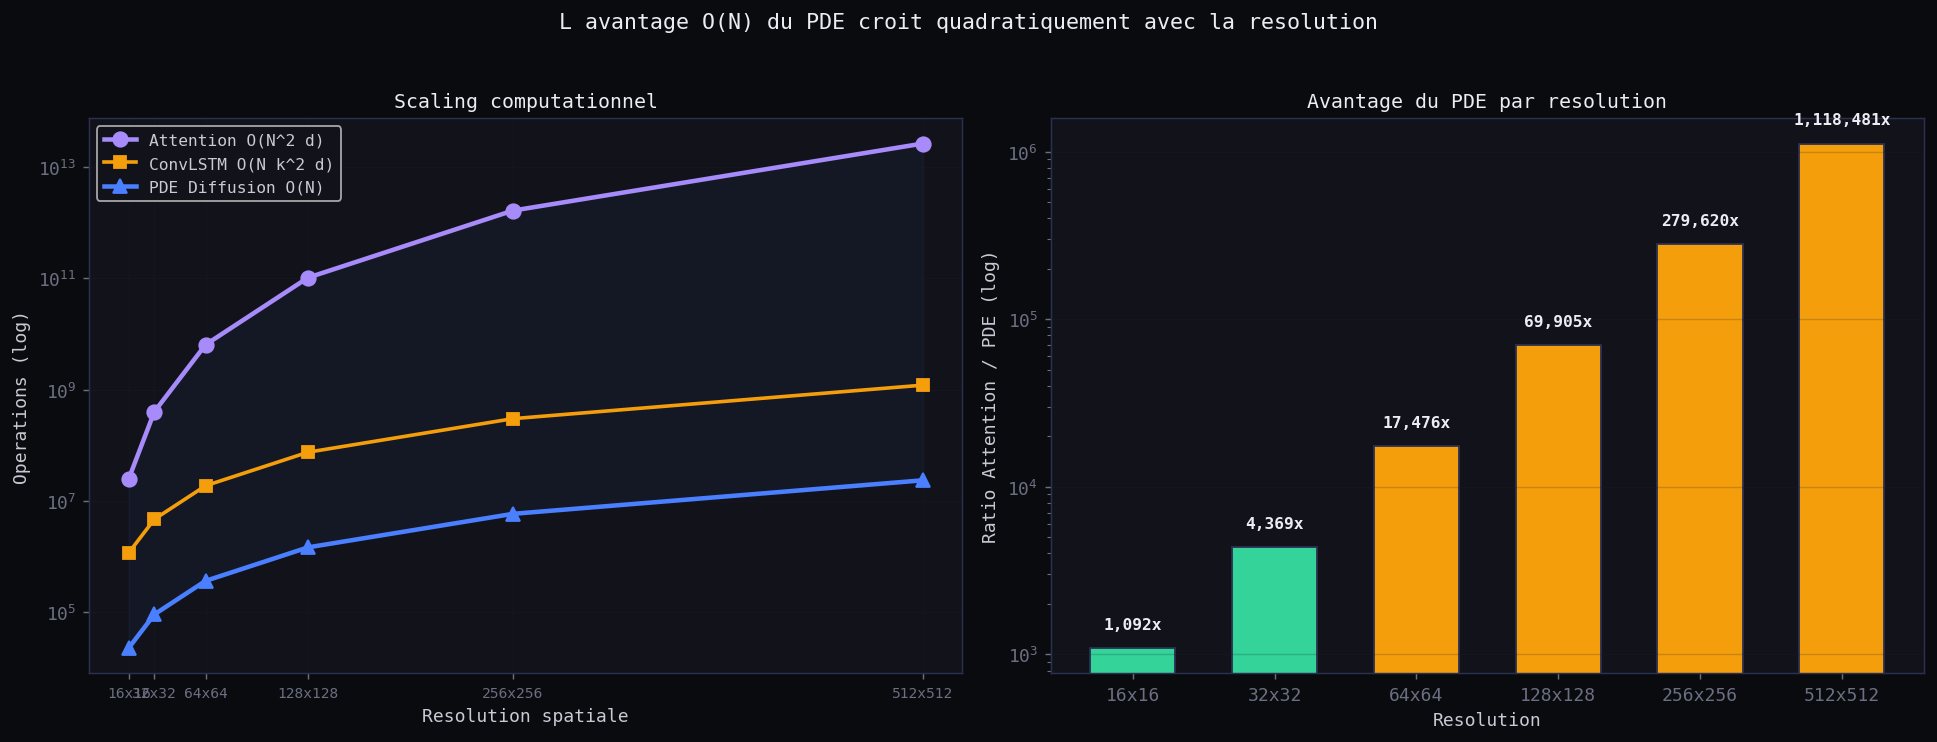

   16x16  (   256 tokens) :        1,092x
   32x32  (  1024 tokens) :        4,369x
   64x64  (  4096 tokens) :       17,476x
  128x128 ( 16384 tokens) :       69,905x
  256x256 ( 65536 tokens) :      279,620x
  512x512 (262144 tokens) :    1,118,481x


In [11]:
# Complexite O(N) vs O(N^2)
resolutions = [16, 32, 64, 128, 256, 512]
d = 128
K_int, L_lay, k_c = 18, 3, 3

ops_att = [L_lay * (r*r)**2 * d for r in resolutions]
ops_pde = [K_int * (r*r) * 5 for r in resolutions]
ops_conv = [(r*r) * k_c**2 * d * 4 for r in resolutions]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

ax1.semilogy(resolutions, ops_att, 'o-', color='#a78bfa', lw=2.5, markersize=8, label='Attention O(N^2 d)', zorder=3)
ax1.semilogy(resolutions, ops_conv, 's-', color='#f59e0b', lw=2, markersize=7, label='ConvLSTM O(N k^2 d)')
ax1.semilogy(resolutions, ops_pde, '^-', color='#4a7fff', lw=2.5, markersize=8, label='PDE Diffusion O(N)', zorder=3)
ax1.fill_between(resolutions, ops_pde, ops_att, alpha=0.05, color='#4a7fff')
ax1.set_xlabel('Resolution spatiale')
ax1.set_ylabel('Operations (log)')
ax1.set_title('Scaling computationnel', fontsize=11, color='#ecedf2')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.set_xticks(resolutions)
ax1.set_xticklabels([f'{r}x{r}' for r in resolutions], fontsize=8)

ratios = [a / p for a, p in zip(ops_att, ops_pde)]
colors_bar = ['#22d3ee' if r < 1000 else '#34d399' if r < 10000 else '#f59e0b' for r in ratios]
ax2.bar([f'{r}x{r}' for r in resolutions], ratios, color=colors_bar, edgecolor='#2a3050', width=0.6)
for i, ratio in enumerate(ratios):
    ax2.text(i, ratio * 1.3, f'{ratio:,.0f}x', ha='center', fontsize=9, color='#ecedf2', fontweight='bold')
ax2.set_yscale('log')
ax2.set_xlabel('Resolution')
ax2.set_ylabel('Ratio Attention / PDE (log)')
ax2.set_title('Avantage du PDE par resolution', fontsize=11, color='#ecedf2')
ax2.grid(True, alpha=0.2, axis='y')

plt.suptitle("L avantage O(N) du PDE croit quadratiquement avec la resolution", fontsize=12, color='#ecedf2', y=1.03)
plt.tight_layout()
plt.show()

for res, ratio in zip(resolutions, ratios):
    print(f"  {res:>3}x{res:<3} ({res*res:>6} tokens) : {ratio:>12,.0f}x")


## 11. Brisure de symetrie spontanee

A partir d'un champ presque **uniforme** (epsilon = 1e-4), le PDE genere spontanement de la **structure spatiale** en quelques pas. C'est un pre-requis pour apprendre des representations spatiales.


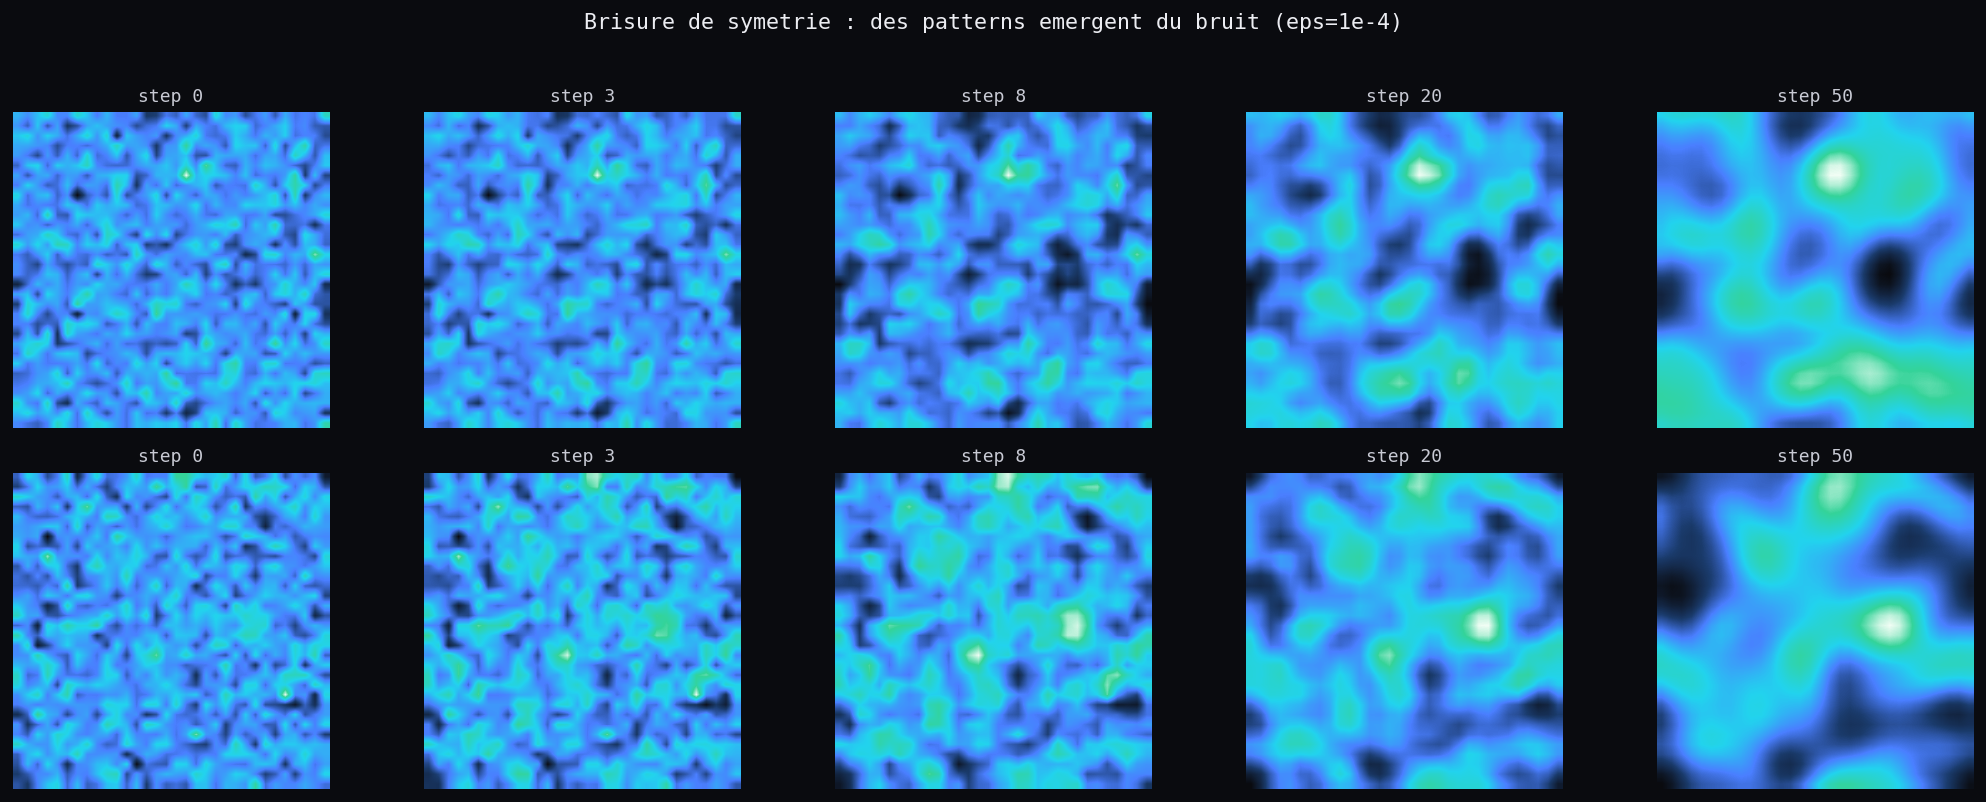

In [12]:
# Brisure de symetrie spontanee
N = 32
K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for row, seed in enumerate([42, 123]):
    np.random.seed(seed)
    u = np.ones((N, N)) * 0.5 + np.random.randn(N, N) * 1e-4
    snapshots = [0, 3, 8, 20, 50]

    for step in range(max(snapshots) + 1):
        if step in snapshots:
            idx = snapshots.index(step)
            axes[row, idx].imshow(u, cmap=fluid_colors, interpolation='bilinear')
            axes[row, idx].set_title(f'step {step}', fontsize=10)
            axes[row, idx].axis('off')
        lap = convolve2d(u, K_lap, mode='same', boundary='wrap')
        u = np.clip(u + 0.3 * (0.15 * lap + u * (1 - u) * (u - 0.3) * 0.8), -2, 3)

    axes[row, 0].set_ylabel(f'Seed {seed}', fontsize=10, color='#ecedf2')

plt.suptitle('Brisure de symetrie : des patterns emergent du bruit (eps=1e-4)', fontsize=12, color='#ecedf2', y=1.02)
plt.tight_layout()
plt.show()


## 12. Stabilite dynamique — RMSNorm comme homeostasie

Le PDE opere en regime **super-critique**. Sans controle, l'energie diverge. RMSNorm joue le role d'homeostat dynamique.


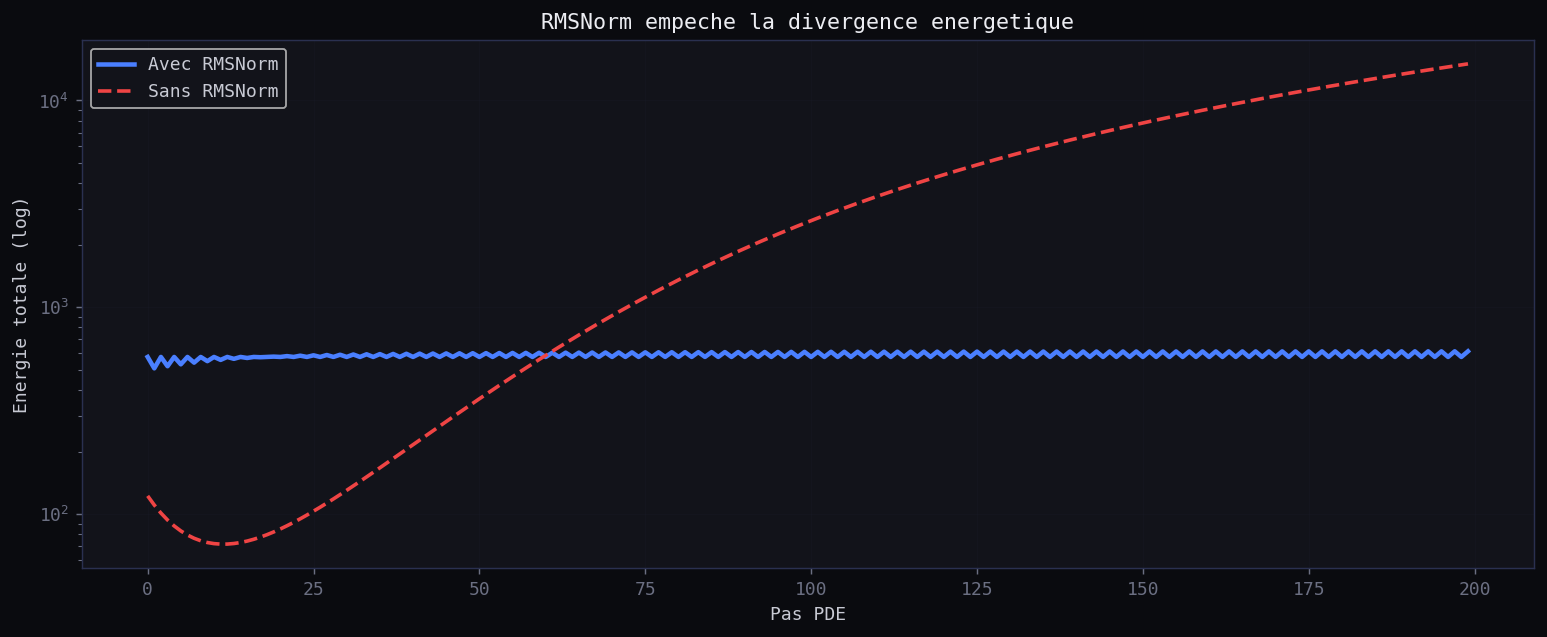

Energie finale avec RMSNorm : 613.3
Energie finale sans RMSNorm : 15035.5
Ratio de divergence         : x123


In [13]:
# Stabilite : avec vs sans RMSNorm
N = 24
K_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)
np.random.seed(42)
u_init = np.random.randn(N, N) * 0.5

def rmsnorm(u):
    return u / (np.sqrt(np.mean(u**2) + 1e-8))

n_steps = 200
D, dt = 0.25, 0.1

u_norm, u_raw = u_init.copy(), u_init.copy()
energy_norm, energy_raw = [], []

for step in range(n_steps):
    lap_n = convolve2d(u_norm, K_lap, mode='same', boundary='wrap')
    u_norm = u_norm + dt * (D * lap_n + np.tanh(u_norm) * 0.5)
    if step % 2 == 0:
        u_norm = rmsnorm(u_norm)
    energy_norm.append(np.sum(u_norm**2))

    lap_r = convolve2d(u_raw, K_lap, mode='same', boundary='wrap')
    u_raw = u_raw + dt * (D * lap_r + np.tanh(u_raw) * 0.5)
    energy_raw.append(np.sum(u_raw**2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(energy_norm, color='#4a7fff', lw=2.5, label='Avec RMSNorm')
ax.semilogy(energy_raw, color='#ef4444', lw=2, ls='--', label='Sans RMSNorm')
ax.set_xlabel('Pas PDE')
ax.set_ylabel('Energie totale (log)')
ax.set_title('RMSNorm empeche la divergence energetique', fontsize=12, color='#ecedf2')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Energie finale avec RMSNorm : {energy_norm[-1]:.1f}")
print(f"Energie finale sans RMSNorm : {energy_raw[-1]:.1f}")
print(f"Ratio de divergence         : x{energy_raw[-1]/energy_raw[0]:.0f}")


## 13. Recapitulatif

| Contribution | Description | Impact |
|---|---|---|
| **PDE comme predicteur** | Laplacien + reaction remplace l'attention | O(N) au lieu de O(N^2) |
| **BeliefField** | Etat spatial persistant GRU + PDE | Accumulation temporelle continue |
| **Auto-reparation** | Laplacien dissipe les erreurs HF | Rollout 1-2 horizons plus stable |
| **Calcul adaptatif** | Arret anticipe par convergence PDE | ~3 pas pour scenes simples |
| **Mecanismes bio** | Inhibition laterale, fatigue, Hebbian | Combattent le channel collapse |
| **RMSNorm** | Normalisation comme regulation dynamique | Systeme borne et stable |

**Limites principales :** pas de conditionnement action, un seul dataset (UCF-101, 64x64), ~800K parametres, 5-8x plus lent a l'entrainement, mecanismes bio non ablatees individuellement.

**Reference :** arXiv:2603.21315 — [github.com/infinition/FluidWorld](https://github.com/infinition/FluidWorld)


In [14]:
print("=" * 55)
print("  FluidWorld — Notebook de demonstration termine")
print("=" * 55)
print()
print("  Principes demontres :")
for p in [
    "Laplacien discret 1D et 2D",
    "Diffusion multi-echelle (dilations {1, 4, 16})",
    "Dynamique reaction-diffusion",
    "Auto-reparation par diffusion (resultat central)",
    "Simulation de rollout autoregressif",
    "Calcul adaptatif (arret anticipe)",
    "BeliefField (ecriture / evolution / lecture)",
    "Mecanismes bio-inspires",
    "Complexite O(N) vs O(N^2)",
    "Brisure de symetrie spontanee",
    "RMSNorm comme homeostasie dynamique",
]:
    print(f"  > {p}")


  FluidWorld — Notebook de demonstration termine

  Principes demontres :
  > Laplacien discret 1D et 2D
  > Diffusion multi-echelle (dilations {1, 4, 16})
  > Dynamique reaction-diffusion
  > Auto-reparation par diffusion (resultat central)
  > Simulation de rollout autoregressif
  > Calcul adaptatif (arret anticipe)
  > BeliefField (ecriture / evolution / lecture)
  > Mecanismes bio-inspires
  > Complexite O(N) vs O(N^2)
  > Brisure de symetrie spontanee
  > RMSNorm comme homeostasie dynamique
